### Model Performance Functions (Run the following cell first!)

In [1]:
import numpy as np
def mean_error(actual, predicted):
    return np.mean(actual - predicted)

def mpe(actual, predicted):
    return np.mean((actual - predicted) / actual)

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def rsquared(actual, predicted):
    return 1 - np.sum((actual - predicted) ** 2) / np.sum((actual - actual.mean()) ** 2)

# Create a dictionary with performance metrics
def model_performance(actual, predicted):
    return {
        'ME': round(mean_error(actual, predicted), 4),
        'RMSE': round(rmse(actual, predicted), 4),
        'MAE': round(mae(actual, predicted), 4),
        'MPE': round(mpe(actual, predicted), 4),
        'MAPE': round(mape(actual, predicted), 4),
        'R-squared': round(rsquared(actual, predicted), 4)
    }

In [2]:
# Import frequently used packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import os
# Define the local folder filename
csv_filename = 'AustralianWines.csv'
# Read the CSV file from the specified path
full_path = os.path.join(r'C:\Users\TobyWong\Desktop\UNCC\6211\6211_Forecasting_lesson\data', csv_filename)
df = pd.read_csv(full_path)
df.head()

,Month,Red
0,1/1/1980,464
1,2/1/1980,675
2,3/1/1980,703
3,4/1/1980,887
4,5/1/1980,1139


In [5]:
# Display data frame and check the data types
display(df)
df.dtypes

,Month,Red
0,1/1/1980,464
1,2/1/1980,675
2,3/1/1980,703
3,4/1/1980,887
4,5/1/1980,1139
...,...,...
175,8/1/1994,2665
176,9/1/1994,2639
177,10/1/1994,2226
178,11/1/1994,2586


Month      str
Red      int64
dtype: object

In [6]:
# Convert the Month column to time series
df['Date']= pd.to_datetime(df['Month'], format='%m/%d/%Y')
wine_ts = pd.Series(df.Red.values, index=df.Date, name='Wine')

In [7]:
# Display the time series data (pandas.Series object)
print(type(wine_ts))
print(wine_ts)

<class 'pandas.Series'>
Date
1980-01-01     464
1980-02-01     675
1980-03-01     703
1980-04-01     887
1980-05-01    1139
              ... 
1994-08-01    2665
1994-09-01    2639
1994-10-01    2226
1994-11-01    2586
1994-12-01    2684
Name: Wine, Length: 180, dtype: int64


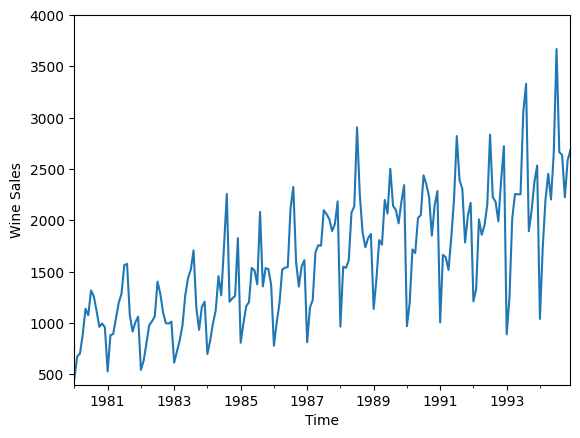

In [8]:
# Plot the time series
wine_plot = wine_ts.plot()
wine_plot.set_xlabel('Time')
wine_plot.set_ylabel('Wine Sales')
wine_plot.set_ylim(400,4000)
plt.show()

**Decomposition:**

The `seasonal_decompose` function from `statsmodels` decomposes a time series into three main components:

- **Trend:** The long-term progression in the data.
- **Seasonal:** Repeating patterns or cycles over a fixed period (e.g., monthly or quarterly).
- **Residual:** The remaining random variation after removing the trend and seasonal components.

The command `sd.plot()` generates a visualization with four subplots, showing:

1. The **Original** time series.
2. The **Trend** component, which reflects long-term changes in the data.
3. The **Seasonal** component, capturing regular patterns or cycles.
4. The **Residuals (or Noise),** representing random variations that are not explained by the trend or seasonal components.

This visualization is valuable for identifying whether the time series exhibits a clear trend or seasonality. It also aids in selecting suitable forecasting models, particularly if seasonality- or trend-based models are appropriate.

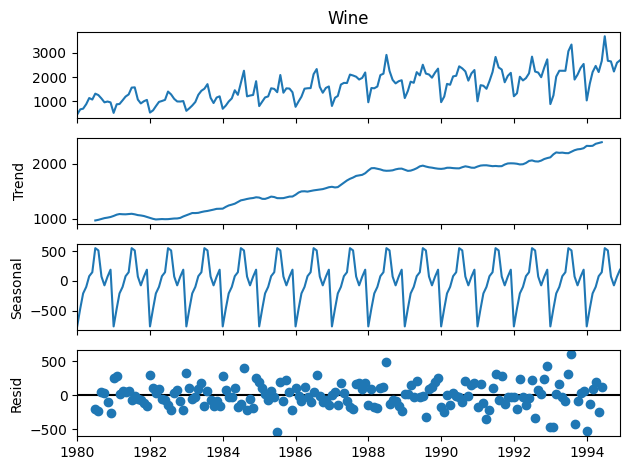

In [24]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
sd = seasonal_decompose(wine_ts, model='additive', period=12)

# This will create a single decomposition plot with 4 subplots
sd.plot()
plt.show()

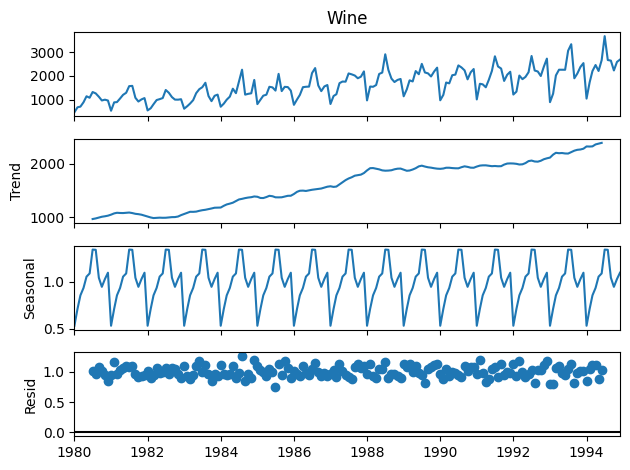

In [25]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
sd = seasonal_decompose(wine_ts, model='multiplicative', period=12)

# This will create a single decomposition plot with 4 subplots
sd.plot()
plt.show()

In [10]:
nValid = 24
nTrain = len(wine_ts) - nValid
train_ts = wine_ts[:nTrain]
valid_ts = wine_ts[nTrain:]


Group 1: Fit Model 1 - Linear trend only(Wine trend)

In [14]:
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools, stattools
# Add a trend term to the time series
ts_df = tsatools.add_trend(wine_ts,trend='ct')
# Add a month term to the time series
ts_df['Month']=ts_df.index.month
nValid = 24
nTrain = len(wine_ts) - nValid
train_df = ts_df[:nTrain]
valid_df = ts_df[nTrain:]
wine_lm = sm.ols(formula='Wine ~ trend',data=train_df).fit()
ts_df

,Wine,const,trend,Month
Date,,,,
1980-01-01,464,1.0,1.0,1
1980-02-01,675,1.0,2.0,2
1980-03-01,703,1.0,3.0,3
1980-04-01,887,1.0,4.0,4
1980-05-01,1139,1.0,5.0,5
...,...,...,...,...
1994-08-01,2665,1.0,176.0,8
1994-09-01,2639,1.0,177.0,9
1994-10-01,2226,1.0,178.0,10


In [15]:
wine_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Wine   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     180.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           9.22e-28
Time:                        18:06:10   Log-Likelihood:                -1143.3
No. Observations:                 156   AIC:                             2291.
Df Residuals:                     154   BIC:                             2297.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    831.8371     59.688     13.936      0.000     713.924     949.750
trend          8.8695      0.660     13.448      0.000       7.567      10.172
==============================================================================
Omnibus:                        1.726   Durbin-Watson:                   1.080
Prob(Omnibus):                  0.422   Jarque-Bera (JB):                1.387
Skew:                          -0.052   Prob(JB):                        0.500
Kurtosis:                       3.450   Cond. No.                         182.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
from dmba import regressionSummary
predict_lm = wine_lm.predict(valid_df)
regressionSummary(valid_ts,predict_lm)


Regression statistics

                      Mean Error (ME) : -35.9661
       Root Mean Squared Error (RMSE) : 606.8201
            Mean Absolute Error (MAE) : 427.9007
          Mean Percentage Error (MPE) : -12.5160
Mean Absolute Percentage Error (MAPE) : 25.2636


In [17]:
pd.Series(model_performance(valid_ts,predict_lm), name = "Performance")

ME           -35.9661
RMSE         606.8201
MAE          427.9007
MPE           -0.1252
MAPE          25.2636
R-squared      0.0719
Name: Performance, dtype: float64

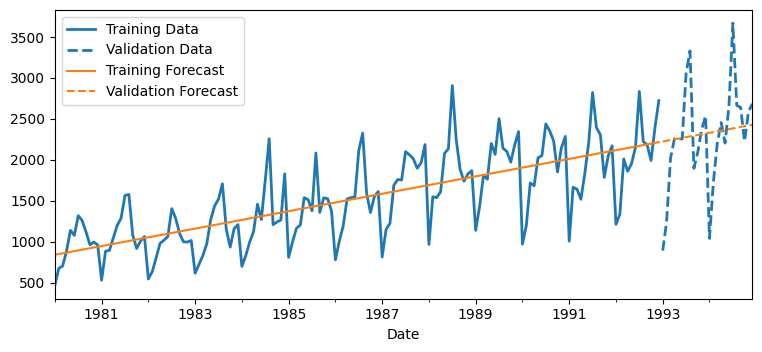

In [20]:
# Blue line for the original time series
# Orange line for the forecasted time series
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,3.75))
train_df.plot(y='Wine',ax=ax,color='C0',linewidth=2, label='Training Data')
valid_df.plot(y='Wine',ax=ax,color='C0',linewidth=2, linestyle='dashed', label='Validation Data')
wine_lm.predict(train_df).plot(color='C1', label='Training Forecast')
wine_lm.predict(valid_df).plot(color='C1',linestyle='dashed', label='Validation Forecast')
ax.legend()
plt.show()

Model 2: Seasonality Only (Wine~C(Month))

In [26]:
wine_lm_season = sm.ols(formula='Wine~C(Month)',data=train_df).fit()
wine_lm_season.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Wine   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     8.406
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.57e-11
Time:                        18:20:07   Log-Likelihood:                -1165.2
No. Observations:                 156   AIC:                             2354.
Df Residuals:                     144   BIC:                             2391.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        811.3077    122.433      6.627      0.000     569.310    1053.305
C(Month)[T.2]    271.3846    173.146      1.567      0.119     -70.851     613.620
C(Month)[T.3]    460.1538    173.146      2.658      0.009     117.918     802.390
C(Month)[T.4]    563.0769    173.146      3.252      0.001     220.841     905.313
C(Month)[T.5]    804.6923    173.146      4.647      0.000     462.457    1146.928
C(Month)[T.6]    847.3077    173.146      4.894      0.000     505.072    1189.543
C(Month)[T.7]   1239.4615    173.146      7.158      0.000     897.226    1581.697
C(Month)[T.8]   1182.5385    173.146      6.830      0.000     840.303    1524.774
C(Month)[T.9]    829.3077    173.146      4.790      0.000     487.072    1171.543
C(Month)[T.10]   664.3846    173.146      3.837      0.000     322.149    1006.620
C(Month)[T.11]   808.6154    173.146      4.670      0.000     466.380    1150.851
C(Month)[T.12]   930.4615    173.146      5.374      0.000     588.226    1272.697
==============================================================================
Omnibus:                       39.734   Durbin-Watson:                   0.292
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                7.908
Skew:                           0.025   Prob(JB):                       0.0192
Kurtosis:                       1.898   Cond. No.                         12.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
predict_lm_season = wine_lm_season.predict(valid_df)
regressionSummary(valid_ts, predict_lm_season)
pd.Series(model_performance(valid_ts,predict_lm_season), name = "Performance")


Regression statistics

                      Mean Error (ME) : 762.2853
       Root Mean Squared Error (RMSE) : 838.6621
            Mean Absolute Error (MAE) : 762.2853
          Mean Percentage Error (MPE) : 31.4759
Mean Absolute Percentage Error (MAPE) : 31.4759


ME           762.2853
RMSE         838.6621
MAE          762.2853
MPE            0.3148
MAPE          31.4759
R-squared     -0.7728
Name: Performance, dtype: float64

In [28]:
pd.Series(model_performance(valid_ts,predict_lm_season), name = "Performance")

ME           762.2853
RMSE         838.6621
MAE          762.2853
MPE            0.3148
MAPE          31.4759
R-squared     -0.7728
Name: Performance, dtype: float64

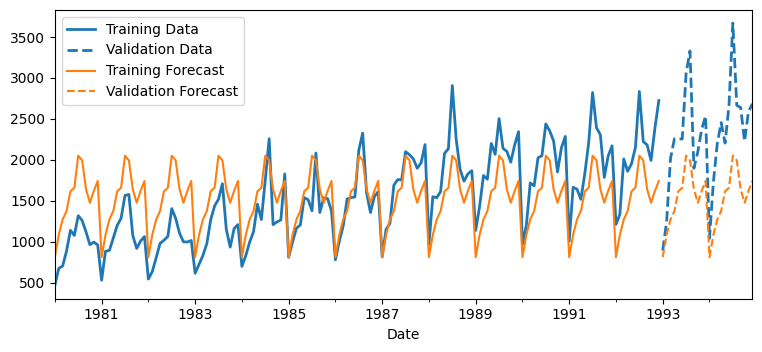

In [29]:
# Blue line for the original time series
# Orange line for the forecasted time series
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,3.75))
train_df.plot(y='Wine',ax=ax,color='C0',linewidth=2, label='Training Data')
valid_df.plot(y='Wine',ax=ax,color='C0',linewidth=2, linestyle='dashed', label='Validation Data')
wine_lm_season.predict(train_df).plot(color='C1', label='Training Forecast')
wine_lm_season.predict(valid_df).plot(color='C1',linestyle='dashed', label='Validation Forecast')
ax.legend()
plt.show()

*Additional Model: Polynomial Trend Only*

In [36]:
wine_lm_poly = sm.ols(formula='Wine ~ trend + np.square(trend)',
data=train_df).fit()
wine_lm_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Wine   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     89.88
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.53e-26
Time:                        18:58:02   Log-Likelihood:                -1143.2
No. Observations:                 156   AIC:                             2292.
Df Residuals:                     153   BIC:                             2302.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          817.5199     90.538      9.030      0.000     638.654     996.386
trend                9.4132      2.662      3.535      0.001       4.153      14.673
np.square(trend)    -0.0035      0.016     -0.211      0.833      -0.036       0.029
==============================================================================
Omnibus:                        1.656   Durbin-Watson:                   1.080
Prob(Omnibus):                  0.437   Jarque-Bera (JB):                1.301
Skew:                          -0.056   Prob(JB):                        0.522
Kurtosis:                       3.433   Cond. No.                     3.34e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.34e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [35]:
predict_lm_poly = wine_lm_poly.predict(valid_df)
regressionSummary(valid_ts,predict_lm_poly)
pd.Series(model_performance(valid_ts,predict_lm_poly), name = "Performance")


Regression statistics

                      Mean Error (ME) : -14.7725
       Root Mean Squared Error (RMSE) : 607.4336
            Mean Absolute Error (MAE) : 430.8799
          Mean Percentage Error (MPE) : -11.5232
Mean Absolute Percentage Error (MAPE) : 25.1757


ME           -14.7725
RMSE         607.4336
MAE          430.8799
MPE           -0.1152
MAPE          25.1757
R-squared      0.0700
Name: Performance, dtype: float64

**Model 3: Trend + Seasonality combined**

In [30]:
modelfomula = 'Wine ~ trend + np.square(trend) + C(Month)'
wine_lm_trendseason = sm.ols(formula=modelfomula, data=train_df).fit()
wine_lm_trendseason.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Wine   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     85.55
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.38e-60
Time:                        18:25:32   Log-Likelihood:                -1033.9
No. Observations:                 156   AIC:                             2096.
Df Residuals:                     142   BIC:                             2139.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          177.5683     68.279      2.601      0.010      42.593     312.543
C(Month)[T.2]      262.8345     75.186      3.496      0.001     114.206     411.463
C(Month)[T.3]      443.0593     75.188      5.893      0.000     294.426     591.692
C(Month)[T.4]      537.4435     75.192      7.148      0.000     388.803     686.084
C(Month)[T.5]      770.5258     75.198     10.247      0.000     621.874     919.178
C(Month)[T.6]      804.6137     75.205     10.699      0.000     655.948     953.279
C(Month)[T.7]     1188.2457     75.213     15.798      0.000    1039.563    1336.928
C(Month)[T.8]     1122.8065     75.223     14.926      0.000     974.104    1271.509
C(Month)[T.9]      761.0652     75.235     10.116      0.000     612.340     909.790
C(Month)[T.10]     587.6373     75.248      7.809      0.000     438.886     736.388
C(Month)[T.11]     723.3688     75.263      9.611      0.000     574.589     872.149
C(Month)[T.12]     836.7215     75.279     11.115      0.000     687.909     985.534
trend                8.9661      1.372      6.536      0.000       6.254      11.678
np.square(trend)    -0.0028      0.008     -0.334      0.739      -0.020       0.014
==============================================================================
Omnibus:                        3.338   Durbin-Watson:                   1.540
Prob(Omnibus):                  0.188   Jarque-Bera (JB):                3.081
Skew:                           0.204   Prob(JB):                        0.214
Kurtosis:                       3.555   Cond. No.                     1.37e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.37e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [31]:
predict_lm_trendseason = wine_lm_trendseason.predict(valid_df)
regressionSummary(valid_ts, predict_lm_trendseason)
pd.Series(model_performance(valid_ts,predict_lm_trendseason), name = "Performance")


Regression statistics

                      Mean Error (ME) : 12.6374
       Root Mean Squared Error (RMSE) : 339.1057
            Mean Absolute Error (MAE) : 259.7121
          Mean Percentage Error (MPE) : -4.8302
Mean Absolute Percentage Error (MAPE) : 14.1887


ME            12.6374
RMSE         339.1057
MAE          259.7121
MPE           -0.0483
MAPE          14.1887
R-squared      0.7102
Name: Performance, dtype: float64

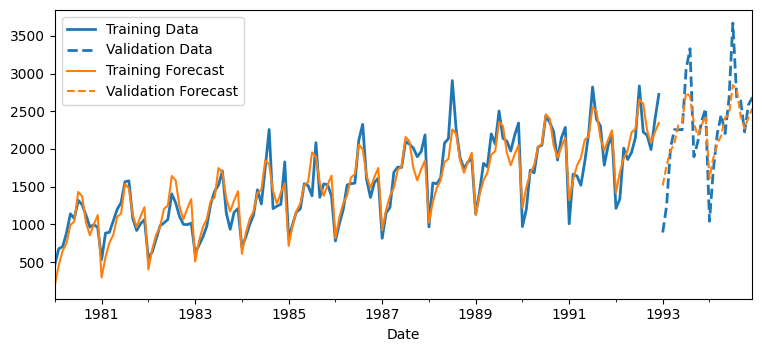

In [32]:
# Blue line for the original time series
# Orange line for the forecasted time series
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,3.75))
train_df.plot(y='Wine',ax=ax,color='C0',linewidth=2, label='Training Data')
valid_df.plot(y='Wine',ax=ax,color='C0',linewidth=2, linestyle='dashed', label='Validation Data')
wine_lm_trendseason.predict(train_df).plot(color='C1', label='Training Forecast')
wine_lm_trendseason.predict(valid_df).plot(color='C1',linestyle='dashed', label='Validation Forecast')
ax.legend()
plt.show()

**Moving Averages**

In [38]:
ma = train_ts.rolling(12).mean()
last_ma = ma.iloc[-1]
train_ts

Date
1980-01-01     464
1980-02-01     675
1980-03-01     703
1980-04-01     887
1980-05-01    1139
              ... 
1992-08-01    2224
1992-09-01    2182
1992-10-01    1992
1992-11-01    2389
1992-12-01    2724
Name: Wine, Length: 156, dtype: int64

In [39]:
ma

Date
1980-01-01            NaN
1980-02-01            NaN
1980-03-01            NaN
1980-04-01            NaN
1980-05-01            NaN
                 ...     
1992-08-01    1991.000000
1992-09-01    1980.666667
1992-10-01    1997.916667
1992-11-01    2026.416667
1992-12-01    2072.500000
Name: Wine, Length: 156, dtype: float64

In [41]:
predict_ma = pd.Series(last_ma,index=valid_ts.index)
predict_ma

Date
1993-01-01    2072.5
1993-02-01    2072.5
1993-03-01    2072.5
1993-04-01    2072.5
1993-05-01    2072.5
1993-06-01    2072.5
1993-07-01    2072.5
1993-08-01    2072.5
1993-09-01    2072.5
1993-10-01    2072.5
1993-11-01    2072.5
1993-12-01    2072.5
1994-01-01    2072.5
1994-02-01    2072.5
1994-03-01    2072.5
1994-04-01    2072.5
1994-05-01    2072.5
1994-06-01    2072.5
1994-07-01    2072.5
1994-08-01    2072.5
1994-09-01    2072.5
1994-10-01    2072.5
1994-11-01    2072.5
1994-12-01    2072.5
dtype: float64

In [42]:
regressionSummary(valid_ts, predict_ma)
pd.Series(model_performance(valid_ts,predict_ma), name = "Performance")


Regression statistics

                      Mean Error (ME) : 217.8750
       Root Mean Squared Error (RMSE) : 666.4985
            Mean Absolute Error (MAE) : 519.1250
          Mean Percentage Error (MPE) : -0.7191
Mean Absolute Percentage Error (MAPE) : 26.7715


ME           217.8750
RMSE         666.4985
MAE          519.1250
MPE           -0.0072
MAPE          26.7715
R-squared     -0.1196
Name: Performance, dtype: float64

**Exponential Smoothing**

In [44]:
from statsmodels.tsa.api import SimpleExpSmoothing
SES = SimpleExpSmoothing(train_ts, initialization_method='estimated').fit()
predict_SES = SES.forecast(len(valid_ts))
predict_SES

c:\Users\TobyWong\Desktop\UNCC\6211\6211_Forecasting_lesson\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


1993-01-01    2568.338286
1993-02-01    2568.338286
1993-03-01    2568.338286
1993-04-01    2568.338286
1993-05-01    2568.338286
1993-06-01    2568.338286
1993-07-01    2568.338286
1993-08-01    2568.338286
1993-09-01    2568.338286
1993-10-01    2568.338286
1993-11-01    2568.338286
1993-12-01    2568.338286
1994-01-01    2568.338286
1994-02-01    2568.338286
1994-03-01    2568.338286
1994-04-01    2568.338286
1994-05-01    2568.338286
1994-06-01    2568.338286
1994-07-01    2568.338286
1994-08-01    2568.338286
1994-09-01    2568.338286
1994-10-01    2568.338286
1994-11-01    2568.338286
1994-12-01    2568.338286
Freq: MS, dtype: float64

In [45]:
SES.model.params

{'smoothing_level': np.float64(0.6493087598800544),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(553.1934333963179),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [46]:
regressionSummary(valid_ts,predict_SES)
pd.Series(model_performance(valid_ts,predict_SES), name = "Performance")


Regression statistics

                      Mean Error (ME) : -277.9633
       Root Mean Squared Error (RMSE) : 688.4870
            Mean Absolute Error (MAE) : 506.6544
          Mean Percentage Error (MPE) : -24.8158
Mean Absolute Percentage Error (MAPE) : 31.7840


ME          -277.9633
RMSE         688.4870
MAE          506.6544
MPE           -0.2482
MAPE          31.7840
R-squared     -0.1947
Name: Performance, dtype: float64